# 1. Load Data and Model

In [869]:
%matplotlib inline

import os, sys, time, pickle, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as st

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 6)

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw
from lifelines import KaplanMeierFitter

# -----------------------
# Output directories
# -----------------------
data_dir = "./outputs/data"
models_dir = "./outputs/models"
plots_dir = "./outputs/plots"
metrics_dir = "./outputs/metrics"

for d in [data_dir, models_dir, plots_dir, metrics_dir]:
    os.makedirs(d, exist_ok=True)

# -----------------------
# Helpers
# -----------------------
def bins(n):
    # safe-ish default histogram binning
    return max(10, int(np.sqrt(n)))

def ci(x, alpha=0.05):
    """mean and (1-alpha) t-interval; returns (mean, halfwidth, lo, hi) rounded"""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    m = float(np.mean(x))
    if n < 2:
        return round(m, 3), np.nan, np.nan, np.nan
    se = st.sem(x)
    tcrit = st.t.ppf(1 - alpha/2, df=n-1)
    hw = float(tcrit * se)
    return round(m, 3), round(hw, 3), round(m - hw, 3), round(m + hw, 3)


In [870]:
# read in pickles (handle your file naming robustly)
X_clinical = pd.read_pickle("./X_clinical.pkl")

# ResNet file name varies across versions; try both
if os.path.exists("./X_resnet.pkl"):
    X_resnet = pd.read_pickle("./X_resnet.pkl")
elif os.path.exists("./X_resnet.pkl"):
    X_resnet = pd.read_pickle("./X_resnet.pkl")
else:
    raise FileNotFoundError("Could not find X_resnet.pkl or X_resnet.pkl in the working directory.")

y_df = pd.read_pickle("./y.pkl")

# align + merge
X_clinical = X_clinical.drop(columns=["Cohort"], errors="ignore")

tmp = X_clinical.merge(X_resnet, left_index=True, right_index=True)
tmp = tmp.merge(y_df.drop(columns=["Cohort"], errors="ignore"), left_index=True, right_index=True)

# keep cohort label from y (preferred)
if "Cohort" in y_df.columns:
    cohort = y_df["Cohort"]
elif "Cohort" in tmp.columns:
    cohort = tmp["Cohort"]
else:
    raise ValueError("Cohort column not found in y.pkl or merged table.")

# final X
X_all = tmp.drop(columns=["Progression Free Survival", "Event"], errors="ignore")
X_all["Cohort"] = cohort

X_discovery = X_all[X_all["Cohort"] == "Discovery"].drop(columns="Cohort")
X_replicate = X_all[X_all["Cohort"] == "Replicate"].drop(columns="Cohort")

# final y as structured arrays for sksurv (Event must be bool)
y_discovery = np.array(
    [(bool(e), float(t)) for e, t in tmp.loc[X_discovery.index, ["Event", "Progression Free Survival"]].values],
    dtype=[("Event", "?"), ("Progression Free Survival", "<f8")],
)

y_replicate = np.array(
    [(bool(e), float(t)) for e, t in tmp.loc[X_replicate.index, ["Event", "Progression Free Survival"]].values],
    dtype=[("Event", "?"), ("Progression Free Survival", "<f8")],
)

print("Discovery:", X_discovery.shape, "Replicate:", X_replicate.shape)
print("Discovery events:", int(np.sum(y_discovery["Event"])), "Replicate events:", int(np.sum(y_replicate["Event"])))


Discovery: (282, 158) Replicate: (78, 158)
Discovery events: 84 Replicate events: 32


# 2. Discovery

## 2.1 Train and Test

In [871]:
import numpy as np
import pandas as pd
import time

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,   # Harrell
    concordance_index_ipcw,       # Uno
)

# -----------------------
# Helpers
# -----------------------
def timeit(start_time):
    t = time.time() - start_time
    return f"{t:.1f}s" if t < 60 else f"{t/60:.1f}min"


def harrell_cindex(y, pred):
    return concordance_index_censored(
        y["Event"], y["Progression Free Survival"], pred
    )[0]


def uno_cindex(y_train, y_test, pred):
    return concordance_index_ipcw(y_train, y_test, pred)[0]


# Callable scorer for GridSearchCV
def harrell_cv_scorer(estimator, X, y):
    pred = estimator.predict(X)
    return harrell_cindex(y, pred)


# -----------------------
# Penalty factors
# -----------------------
clinical_penalty = 0.3
penalty_factor = np.ones(X_discovery.shape[1], dtype=float)
penalty_factor[: X_clinical.shape[1]] = clinical_penalty


# -----------------------
# CV folds (robust selection)
# -----------------------
n_events = int(np.sum(y_discovery["Event"]))
if n_events < 10:
    n_splits = 3
elif n_events < 20:
    n_splits = 5
else:
    n_splits = 10

outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f"Using n_splits={n_splits} (events={n_events})")


# -----------------------
# Regularization grids
# -----------------------
l1_grid = [0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 1.0]
n_alphas = 100

# IMPORTANT: raise alpha_min_ratio to avoid tiny alphas that cause blow-ups
alpha_min_ratio = 0.1 
max_iter = 50000

# Optional: alpha floor (absolute). Use if you still see blow-ups.
alpha_floor = None      # e.g. 1e-4 or 1e-3


# -----------------------
# Nested CV
# -----------------------
cv_rows = []
outer_s = time.time()

# For Windows debugging, set n_jobs=1 first; switch back to -1 after stable.
n_jobs = 1

for fold_idx, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_discovery, y_discovery["Event"]), start=1
):
    fold_s = time.time()

    X_train = X_discovery.iloc[train_idx, :]
    X_test  = X_discovery.iloc[test_idx, :]
    y_train = y_discovery[train_idx]
    y_test  = y_discovery[test_idx]

    inner_splits = list(inner_cv.split(X_train, y_train["Event"]))

    best_model = None
    best_inner_harrell = -np.inf
    best_params = None

    for l1 in l1_grid:
        # 1) Fit path on TRAIN to get alphas for this l1_ratio
        path_model = CoxnetSurvivalAnalysis(
            l1_ratio=l1,
            penalty_factor=penalty_factor,
            n_alphas=n_alphas,
            alpha_min_ratio=alpha_min_ratio,
            fit_baseline_model=True,
            max_iter=max_iter,
        )
        path_model.fit(X_train, y_train)
        alphas = np.array(path_model.alphas_, dtype=float)

        # Optional absolute floor to remove extremely small alphas
        if alpha_floor is not None:
            alphas = alphas[alphas >= alpha_floor]

        if len(alphas) == 0:
            continue

        base = CoxnetSurvivalAnalysis(
            l1_ratio=l1,
            penalty_factor=penalty_factor,
            fit_baseline_model=True,
            max_iter=max_iter,
        )

        gcv = GridSearchCV(
            estimator=base,
            param_grid={"alphas": [[a] for a in alphas]},
            scoring=harrell_cv_scorer,
            cv=inner_splits,
            n_jobs=n_jobs,
            refit=True,
            # KEY: don't crash whole run if some alphas blow up
            error_score=np.nan,
            return_train_score=False,
        )

        gcv.fit(X_train, y_train)

        # If everything failed -> best_score_ may be nan
        score = gcv.best_score_
        if score is None or (isinstance(score, float) and np.isnan(score)):
            continue

        score = float(score)
        if score > best_inner_harrell:
            best_inner_harrell = score
            best_model = gcv.best_estimator_
            best_params = {
                "l1_ratio": float(l1),
                "alpha": float(gcv.best_params_["alphas"][0]),
            }

    if best_model is None:
        raise RuntimeError(
            f"Fold {fold_idx}: all candidate fits failed (likely alpha too small still). "
            f"Try increasing alpha_min_ratio (e.g., 0.2) or setting alpha_floor (e.g., 1e-3)."
        )

    # ---- Outer fold evaluation (consistent: Harrell + Uno only) ----
    pred_test = best_model.predict(X_test)
    har = harrell_cindex(y_test, pred_test)
    uno = uno_cindex(y_train, y_test, pred_test)
    
    cv_rows.append({
        "fold": fold_idx,
        "best_estimator": best_model,
        "inner_harrell": best_inner_harrell,
        "harrell": har,
        "uno": uno,
        "best_l1_ratio": best_params["l1_ratio"],
        "best_alpha": best_params["alpha"],
    })
    
    print(
        f"Fold {fold_idx}/{n_splits} in {timeit(fold_s)} | "
        f"Harrell={har:.3f} Uno={uno:.3f} | "
        f"inner(Harrell)={best_inner_harrell:.3f} | "
        f"l1_ratio={best_params['l1_ratio']:.2f}, alpha={best_params['alpha']:.4g}"
)


cv_results = pd.DataFrame(cv_rows)
print(f"\nNested CV finished in {timeit(outer_s)}")
cv_results


Using n_splits=10 (events=84)
Fold 1/10 in 12.8s | Harrell=0.671 Uno=0.644 | inner(Harrell)=0.740 | l1_ratio=1.00, alpha=0.04062
Fold 2/10 in 11.8s | Harrell=0.759 Uno=0.731 | inner(Harrell)=0.720 | l1_ratio=0.80, alpha=0.05699
Fold 3/10 in 11.7s | Harrell=0.800 Uno=0.809 | inner(Harrell)=0.728 | l1_ratio=1.00, alpha=0.04931
Fold 4/10 in 11.6s | Harrell=0.635 Uno=0.690 | inner(Harrell)=0.742 | l1_ratio=1.00, alpha=0.05678
Fold 5/10 in 12.5s | Harrell=0.693 Uno=0.514 | inner(Harrell)=0.733 | l1_ratio=1.00, alpha=0.04761
Fold 6/10 in 11.4s | Harrell=0.667 Uno=0.620 | inner(Harrell)=0.743 | l1_ratio=1.00, alpha=0.04144
Fold 7/10 in 11.4s | Harrell=0.869 Uno=0.916 | inner(Harrell)=0.727 | l1_ratio=1.00, alpha=0.03976
Fold 8/10 in 11.3s | Harrell=0.735 Uno=0.703 | inner(Harrell)=0.716 | l1_ratio=0.80, alpha=0.06135
Fold 9/10 in 11.3s | Harrell=0.790 Uno=0.694 | inner(Harrell)=0.742 | l1_ratio=1.00, alpha=0.07599
Fold 10/10 in 11.6s | Harrell=0.685 Uno=0.521 | inner(Harrell)=0.722 | l1_ratio

,fold,best_estimator,inner_harrell,harrell,uno,best_l1_ratio,best_alpha
0,1,CoxnetSurvivalAnalysis(alphas=[np.float64(0.04...,0.739599,0.670520,0.644341,1.0,0.040623
1,2,CoxnetSurvivalAnalysis(alphas=[np.float64(0.05...,0.720000,0.759036,0.730965,0.8,0.056992
2,3,CoxnetSurvivalAnalysis(alphas=[np.float64(0.04...,0.727715,0.800000,0.809477,1.0,0.049314
3,4,CoxnetSurvivalAnalysis(alphas=[np.float64(0.05...,0.742010,0.635359,0.690422,1.0,0.056775
4,5,CoxnetSurvivalAnalysis(alphas=[np.float64(0.04...,0.732775,0.692913,0.514245,1.0,0.047610
5,6,CoxnetSurvivalAnalysis(alphas=[np.float64(0.04...,0.742625,0.666667,0.619680,1.0,0.041440
6,7,CoxnetSurvivalAnalysis(alphas=[np.float64(0.03...,0.726556,0.868750,0.916329,1.0,0.039764
7,8,CoxnetSurvivalAnalysis(alphas=[np.float64(0.06...,0.716440,0.734694,0.702902,0.8,0.061353
8,9,CoxnetSurvivalAnalysis(alphas=[np.float64(0.07...,0.741747,0.790210,0.693823,1.0,0.075995
9,10,CoxnetSurvivalAnalysis(alphas=[np.float64(0.11...,0.722221,0.685185,0.520690,0.7,0.114719


In [872]:
n_jobs = -1

In [873]:
# Print results and save to file
scorings = ["harrell", "uno"]
metrics_text = []

for scoring in scorings:
    c, u, l, h = ci(cv_results[scoring])
    metric_str = f"{scoring}: {c}  CI: +/-{u}  [{l}, {h}]"
    print(metric_str)
    metrics_text.append(metric_str)

with open(os.path.join(metrics_dir, "cv_metrics.txt"), "w") as f:
    f.write("\n".join(metrics_text))

cv_results.to_csv(os.path.join(metrics_dir, "cv_results.csv"), index=False)


harrell: 0.73  CI: +/-0.053  [0.678, 0.783]
uno: 0.684  CI: +/-0.087  [0.597, 0.771]


In [874]:
final_l1_ratio = 1.0  # dominant choice
final_alpha = np.median(cv_results["best_alpha"])


In [875]:
final_alpha

np.float64(0.05304450817384313)

In [876]:
estimator = CoxnetSurvivalAnalysis(
    l1_ratio=final_l1_ratio,
    alphas=[final_alpha],
    penalty_factor=penalty_factor,
    fit_baseline_model=True,
)
estimator.fit(X_discovery, y_discovery)


,n_alphas,100
,alphas,[np.float64(0....4450817384313)]
,alpha_min_ratio,'auto'
,l1_ratio,1.0
,penalty_factor,"array([0.3, 0... 1. , 1. ])"
,normalize,False
,copy_X,True
,tol,1e-07
,max_iter,100000
,verbose,False
,fit_baseline_model,True


## 2.2 Group Risk Scores

Saved refit estimator -> ./outputs/models/estimator.pkl
Median threshold: -0.1256426243281814


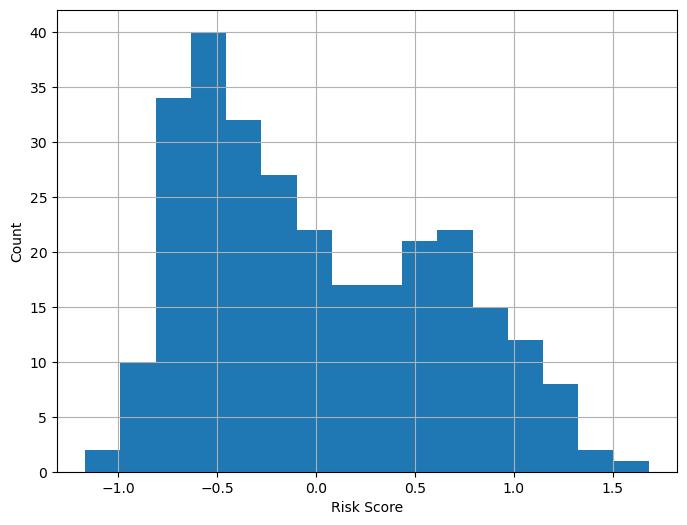

T-statistic: 26.5899, p-value: 0.0000


In [877]:
# save fitted model
with open(os.path.join(models_dir, "estimator.pkl"), "wb") as f:
    pickle.dump(estimator, f)
print(f"Saved refit estimator -> {models_dir}/estimator.pkl")


risk_discovery = pd.DataFrame(
    {"Risk Score": estimator.predict(X_discovery)},
    index=X_discovery.index
)
risk_discovery["Event"] = y_discovery["Event"].astype(int)
risk_discovery["Progression Free Survival"] = y_discovery["Progression Free Survival"].astype(float)

median_threshold = float(risk_discovery["Risk Score"].median())
risk_discovery["Risk Group"] = np.where(
    risk_discovery["Risk Score"] > median_threshold, "High", "Low"
)

with open(os.path.join(data_dir, "discovery_results.pkl"), "wb") as f:
    pickle.dump(risk_discovery, f)
with open(os.path.join(data_dir, "risk_threshold.pkl"), "wb") as f:
    pickle.dump({"median_threshold": median_threshold}, f)

#  Also save threshold as txt
with open(os.path.join(metrics_dir, "risk_thresholds.txt"), "w") as f:
    f.write(f"Risk categorization: Low vs High\n")
    f.write(f"Threshold (50th percentile/median): {median_threshold}\n")
    f.write(f"Low: Risk Score <= {median_threshold}\n")
    f.write(f"High: Risk Score > {median_threshold}\n")
    
# Also save as CSV
risk_discovery.to_csv(os.path.join(data_dir, "discovery_results.csv"), index=True)

print(f"Median threshold: {median_threshold}")

plt.figure(figsize=(8, 6))
risk_discovery["Risk Score"].hist(bins=bins(risk_discovery.shape[0]))
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.savefig(os.path.join(plots_dir, "discovery_risk_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

from scipy.stats import ttest_ind
high_scores = risk_discovery[risk_discovery["Risk Group"] == "High"]["Risk Score"]
low_scores  = risk_discovery[risk_discovery["Risk Group"] == "Low"]["Risk Score"]
t_stat, p_val = ttest_ind(high_scores, low_scores)
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")

with open(os.path.join(metrics_dir, "ttest_results.txt"), "w") as f:
    f.write(f"Independent t-test (High vs Low Risk)\n")
    f.write(f"T-statistic: {t_stat}\n")
    f.write(f"p-value: {p_val}\n")
    f.write(f"Median threshold: {median_threshold}\n")

In [878]:
import numpy as np
import pandas as pd

# make sure coef is 1D
final_coef = np.asarray(estimator.coef_).reshape(-1)

# extract the l1_ratio and alpha used by the final estimator
final_l1 = float(getattr(estimator, "l1_ratio", np.nan))
final_alpha = float(np.asarray(getattr(estimator, "alphas", [np.nan])).reshape(-1)[0])

print("Final l1_ratio:", final_l1)
print("Final alpha:", final_alpha)
print("Nonzero features:", int(np.sum(np.abs(final_coef) > 1e-12)))


Final l1_ratio: 1.0
Final alpha: 0.05304450817384313
Nonzero features: 12


In [879]:
import numpy as np
import pandas as pd
from sksurv.linear_model import CoxnetSurvivalAnalysis

# -----------------------
# Bootstrap settings
# -----------------------
B = 500
seed = 42
rng = np.random.default_rng(seed)

tol = 1e-12
feature_names = X_discovery.columns.to_list()
p = len(feature_names)

# Use the SAME tuned hyperparameters in each bootstrap
# (this gives "uncertainty of the fixed modeling choice")
boot_l1_ratio = float(final_l1)
boot_alpha = float(final_alpha)

# penalty_factor must match your original setup
# (recreate it here if needed)
# penalty_factor = np.ones(p); penalty_factor[:X_clinical.shape[1]] = clinical_penalty

# Storage
coef_boot = np.full((B, p), np.nan, dtype=float)
failed = 0

X_np = X_discovery.to_numpy()
n = X_np.shape[0]

print(f"Bootstrapping {B} fits...")

for b in range(B):
    idx = rng.integers(0, n, size=n)  # sample with replacement

    Xb = X_discovery.iloc[idx, :]
    yb = y_discovery[idx]

    # Fit Coxnet at FIXED alpha (single value) and FIXED l1_ratio
    model_b = CoxnetSurvivalAnalysis(
        l1_ratio=boot_l1_ratio,
        alphas=[boot_alpha],
        penalty_factor=penalty_factor,
        fit_baseline_model=False,
        max_iter=50000,
    )

    try:
        model_b.fit(Xb, yb)
        cb = np.asarray(model_b.coef_).reshape(-1)
        coef_boot[b, :] = cb
    except Exception:
        failed += 1
        continue

print(f"Done. Failed fits: {failed}/{B} ({failed/B:.1%})")


Bootstrapping 500 fits...
Done. Failed fits: 0/500 (0.0%)


In [889]:
import numpy as np
import pandas as pd

# Drop rows that failed (all nan)
ok = ~np.isnan(coef_boot).all(axis=1)
coef_ok = coef_boot[ok, :]
B_ok = coef_ok.shape[0]

if B_ok < 30:
    raise RuntimeError(f"Too few successful bootstrap fits ({B_ok}). Consider increasing alpha or B.")

# Selection frequency = fraction of bootstrap fits where coef != 0
selected = np.abs(coef_ok) > tol
sel_freq = selected.mean(axis=0)

# Bootstrap summaries for coefficients
coef_med = np.nanmedian(coef_ok, axis=0)
coef_lo = np.nanpercentile(coef_ok, 2.5, axis=0)
coef_hi = np.nanpercentile(coef_ok, 97.5, axis=0)

# Convert to HR
hr_med = np.exp(coef_med)
hr_lo = np.exp(coef_lo)
hr_hi = np.exp(coef_hi)

forest = pd.DataFrame({
    "Feature": feature_names,
    "Selection_Frequency": sel_freq,
    "Coef_Median": coef_med,
    "Coef_2.5%": coef_lo,
    "Coef_97.5%": coef_hi,
    "HR_Median": hr_med,
    "HR_2.5%": hr_lo,
    "HR_97.5%": hr_hi,
})

# Optional: label clinical vs Resnet (assuming clinical are first)
n_clin = X_clinical.shape[1]
forest["Type"] = ["Clinical" if i < n_clin else "ResNet" for i in range(p)]

# Keep features that are "stably selected" or nonzero in final model
final_nonzero = np.abs(np.asarray(estimator.coef_).reshape(-1)) > tol
forest["Nonzero_in_Final"] = final_nonzero

# Filter for interpretability: selected >= 20% OR in final model
forest_filt = forest[forest["Nonzero_in_Final"]].copy()

# Sort by |coef| or HR
forest_filt = forest_filt.sort_values("Selection_Frequency", ascending=False)

forest_filt.to_csv(os.path.join(data_dir, "bootstrap_forest.csv"), index=False)
forest_filt.head(30)


,Feature,Selection_Frequency,Coef_Median,Coef_2.5%,Coef_97.5%,HR_Median,HR_2.5%,HR_97.5%,Type,Nonzero_in_Final
4,Extent of Tumor Resection,0.998,-1.439280,-2.157679,-0.599145,0.237098,0.115593,0.549281,Clinical,True
1,Age at Diagnosis,0.902,-0.167461,-0.413716,0.000000,0.845810,0.661189,1.000000,Clinical,True
137,feature_472,0.818,0.134515,0.000000,0.395484,1.143982,1.000000,1.485102,ResNet,True
2,Tumor Location,0.814,-0.113546,-0.425951,0.000000,0.892663,0.653148,1.000000,Clinical,True
5,Chemotherapy,0.712,0.171301,0.000000,0.698104,1.186848,1.000000,2.009938,Clinical,True
83,feature_348,0.610,-0.040475,-0.311578,0.000000,0.960333,0.732290,1.000000,ResNet,True
85,feature_353,0.596,-0.029454,-0.269798,0.000000,0.970975,0.763534,1.000000,ResNet,True
148,feature_495,0.550,-0.011979,-0.234595,0.000000,0.988092,0.790891,1.000000,ResNet,True
105,feature_390,0.392,0.000000,0.000000,0.196930,1.000000,1.000000,1.217659,ResNet,True
60,feature_280,0.380,0.000000,0.000000,0.230518,1.000000,1.000000,1.259252,ResNet,True


In [890]:
# ============================================================
# BOOTSTRAP SUMMARIES + FOREST TABLE
# ============================================================
import numpy as np
import pandas as pd

# Drop failed bootstrap fits
ok      = ~np.isnan(coef_boot).all(axis=1)
coef_ok = coef_boot[ok, :]
B_ok    = coef_ok.shape[0]

if B_ok < 30:
    raise RuntimeError(f"Too few successful bootstrap fits ({B_ok}).")

print(f"Successful bootstrap fits: {B_ok}/{B}")

# Per-feature summaries
tol      = 1e-12
selected = np.abs(coef_ok) > tol
sel_freq = selected.mean(axis=0)

coef_med = np.nanmedian(coef_ok,           axis=0)
coef_lo  = np.nanpercentile(coef_ok,  2.5, axis=0)
coef_hi  = np.nanpercentile(coef_ok, 97.5, axis=0)

hr_med   = np.exp(coef_med)
hr_lo    = np.exp(coef_lo)
hr_hi    = np.exp(coef_hi)

# Build forest table
n_clin       = X_clinical.shape[1]
final_nonzero = np.abs(np.asarray(estimator.coef_).reshape(-1)) > tol

forest = pd.DataFrame({
    "Feature"            : feature_names,
    "Type"               : ["Clinical" if i < n_clin else "Radiomic" for i in range(p)],
    "Selection_Frequency": sel_freq,
    "Coef_Median"        : coef_med,
    "Coef_2.5%"          : coef_lo,
    "Coef_97.5%"         : coef_hi,
    "HR_Median"          : hr_med,
    "HR_2.5%"            : hr_lo,
    "HR_97.5%"           : hr_hi,
    "Nonzero_in_Final"   : final_nonzero,
})

# Keep only features nonzero in final model
forest_filt = forest[forest["Nonzero_in_Final"]].copy()
forest_filt = forest_filt.sort_values("Selection_Frequency", ascending=False)

forest_filt.to_csv(os.path.join(data_dir, "bootstrap_forest.csv"), index=False)
print(f"Selected features: {len(forest_filt)}")
display(forest_filt[[
    "Feature", "Type", "Selection_Frequency",
    "HR_Median", "HR_2.5%", "HR_97.5%"
]].head(30))

Successful bootstrap fits: 500/500
Selected features: 12


,Feature,Type,Selection_Frequency,HR_Median,HR_2.5%,HR_97.5%
4,Extent of Tumor Resection,Clinical,0.998,0.237098,0.115593,0.549281
1,Age at Diagnosis,Clinical,0.902,0.845810,0.661189,1.000000
137,feature_472,Radiomic,0.818,1.143982,1.000000,1.485102
2,Tumor Location,Clinical,0.814,0.892663,0.653148,1.000000
5,Chemotherapy,Clinical,0.712,1.186848,1.000000,2.009938
83,feature_348,Radiomic,0.610,0.960333,0.732290,1.000000
85,feature_353,Radiomic,0.596,0.970975,0.763534,1.000000
148,feature_495,Radiomic,0.550,0.988092,0.790891,1.000000
105,feature_390,Radiomic,0.392,1.000000,1.000000,1.217659
60,feature_280,Radiomic,0.380,1.000000,1.000000,1.259252


In [892]:
# ============================================================
# UNIVARIATE COX P-VALUES FOR SELECTED FEATURES
# ============================================================
from lifelines import CoxPHFitter

selected_features = forest_filt["Feature"].tolist()
uni_results       = []
failed_feats      = []

for feat in selected_features:
    try:
        df_uni = pd.DataFrame({
            "T"    : y_discovery["Progression Free Survival"],
            "E"    : y_discovery["Event"].astype(int),
            "feat" : X_discovery[feat].values,
        })
        cph = CoxPHFitter()
        cph.fit(df_uni, duration_col="T", event_col="E")
        row = cph.summary.loc["feat"]
        uni_results.append({
            "Feature"   : feat,
            "HR_uni"    : round(float(row["exp(coef)"]),            3),
            "HR_lo_uni" : round(float(row["exp(coef) lower 95%"]),  3),
            "HR_hi_uni" : round(float(row["exp(coef) upper 95%"]),  3),
            "p_uni"     : float(row["p"]),
        })
    except Exception as e:
        failed_feats.append(feat)
        print(f"  FAILED: {feat} -> {e}")

print(f"Successful: {len(uni_results)}, Failed: {len(failed_feats)}")

uni_df = pd.DataFrame(uni_results)

# ---- drop stale columns before merge ----
stale = ["HR_uni","HR_lo_uni","HR_hi_uni","p_uni","p_display"]
forest_filt = forest_filt.drop(columns=[c for c in stale if c in forest_filt.columns])

# ---- merge ----
forest_filt = forest_filt.merge(uni_df, on="Feature", how="left")

# ---- hard check ----
print("Columns after merge:", forest_filt.columns.tolist())
print("p_uni nulls:", forest_filt["p_uni"].isna().sum())
print(forest_filt[["Feature","p_uni"]].to_string())

def fmt_p(p):
    if pd.isna(p):  return "NA"
    if p < 0.001:   return "p<0.001"
    else:           return f"p={p:.3f}"

forest_filt["p_display"] = forest_filt["p_uni"].apply(fmt_p)
forest_filt.to_csv(os.path.join(data_dir, "bootstrap_forest.csv"), index=False)

display(forest_filt[[
    "Feature", "Type",
    "HR_uni", "HR_lo_uni", "HR_hi_uni", "p_display"
]].sort_values("p_display"))   # <-- sort by p_display string, not p_uni, as a safe fallback

Successful: 12, Failed: 0
Columns after merge: ['Feature', 'Type', 'Selection_Frequency', 'Coef_Median', 'Coef_2.5%', 'Coef_97.5%', 'HR_Median', 'HR_2.5%', 'HR_97.5%', 'Nonzero_in_Final', 'HR_uni', 'HR_lo_uni', 'HR_hi_uni', 'p_uni']
p_uni nulls: 0
                      Feature         p_uni
0   Extent of Tumor Resection  4.726028e-11
1            Age at Diagnosis  1.505285e-02
2                 feature_472  5.261723e-03
3              Tumor Location  3.352206e-04
4                Chemotherapy  4.617711e-06
5                 feature_348  2.432966e-03
6                 feature_353  2.916560e-03
7                 feature_495  5.495452e-02
8                 feature_390  5.163420e-02
9                 feature_280  1.979974e-01
10                feature_403  1.421073e-01
11                feature_157  2.629858e-02


,Feature,Type,HR_uni,HR_lo_uni,HR_hi_uni,p_display
0,Extent of Tumor Resection,Clinical,0.125,0.067,0.232,p<0.001
3,Tumor Location,Clinical,0.665,0.532,0.831,p<0.001
4,Chemotherapy,Clinical,2.761,1.788,4.263,p<0.001
5,feature_348,Radiomic,0.685,0.536,0.875,p=0.002
6,feature_353,Radiomic,0.683,0.531,0.878,p=0.003
2,feature_472,Radiomic,1.335,1.090,1.636,p=0.005
1,Age at Diagnosis,Clinical,0.751,0.596,0.946,p=0.015
11,feature_157,Radiomic,1.310,1.032,1.661,p=0.026
8,feature_390,Radiomic,1.241,0.998,1.543,p=0.052
7,feature_495,Radiomic,0.787,0.616,1.005,p=0.055


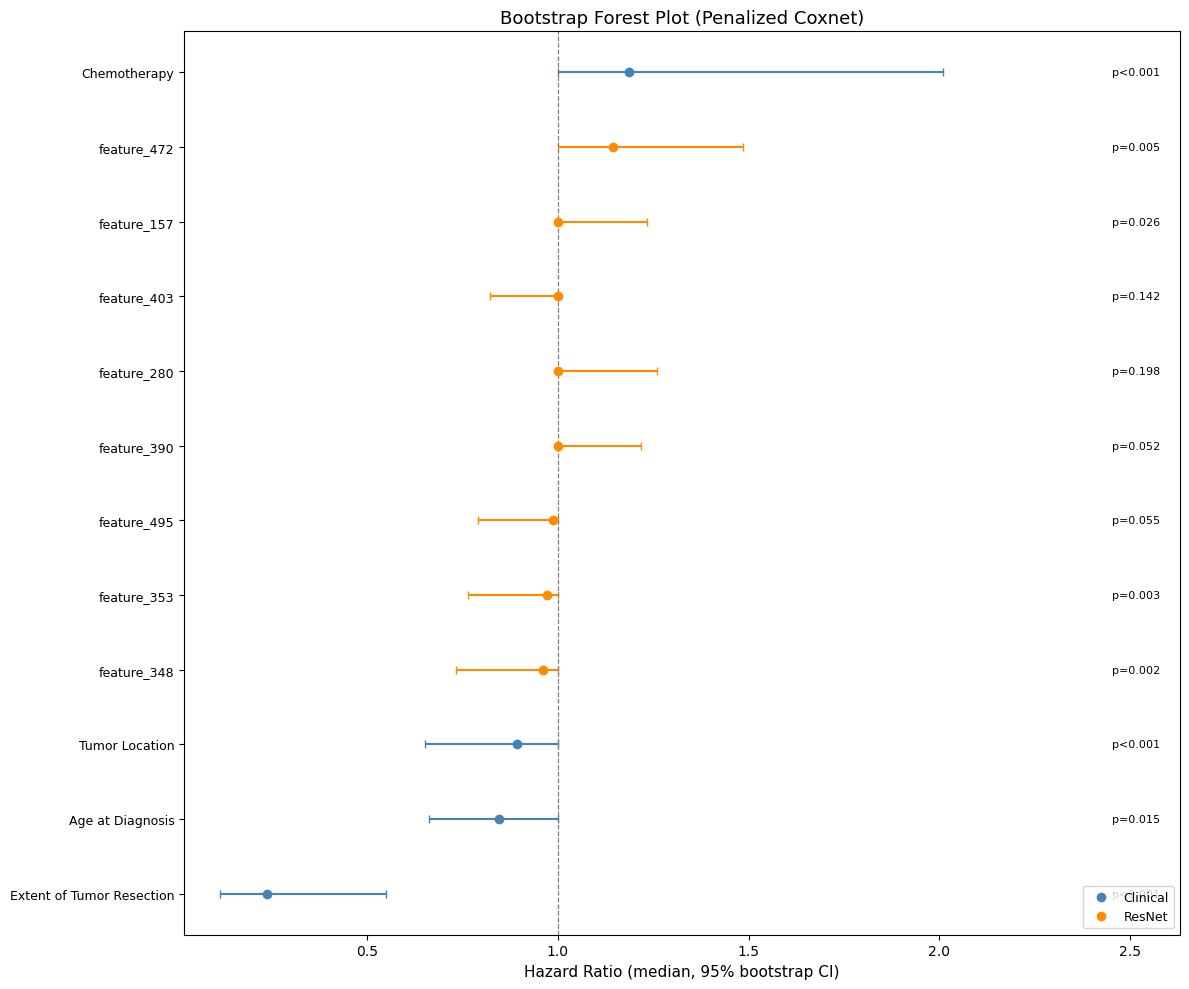

In [894]:
# ============================================================
# FOREST PLOT (bootstrap HRs + univariate p-values)
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

top  = forest_filt.sort_values("Selection_Frequency", ascending=False).head(25).copy()
top  = top.sort_values("HR_Median")
ypos = np.arange(len(top))

fig, ax = plt.subplots(figsize=(12, 10))

colors = top["Type"].map({"Clinical": "steelblue", "Radiomic": "darkorange"})
for i, (_, row) in enumerate(top.iterrows()):
    ax.errorbar(
        row["HR_Median"], i,
        xerr=[[row["HR_Median"] - row["HR_2.5%"]],
              [row["HR_97.5%"] - row["HR_Median"]]],
        fmt="o", color=colors.iloc[i], capsize=3, markersize=6
    )

ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.9)
ax.set_yticks(ypos)
ax.set_yticklabels(top["Feature"], fontsize=9)
ax.set_xlabel("Hazard Ratio (median, 95% bootstrap CI)", fontsize=11)
ax.set_title("Bootstrap Forest Plot (Penalized Coxnet)", fontsize=13)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",  markersize=8, label="Clinical"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="darkorange", markersize=8, label="ResNet"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

# Fix x-axis limit to make room for p-value annotations
x_lo, x_hi = ax.get_xlim()
ax.set_xlim(x_lo, x_hi * 1.25)

# Annotate with p-values
x_right = ax.get_xlim()[1]
for i, (_, row) in enumerate(top.iterrows()):
    ax.text(
        x_right * 0.98, i,
        row["p_display"],
        va="center", ha="right", fontsize=8
    )

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "bootstrap_forest_plot.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

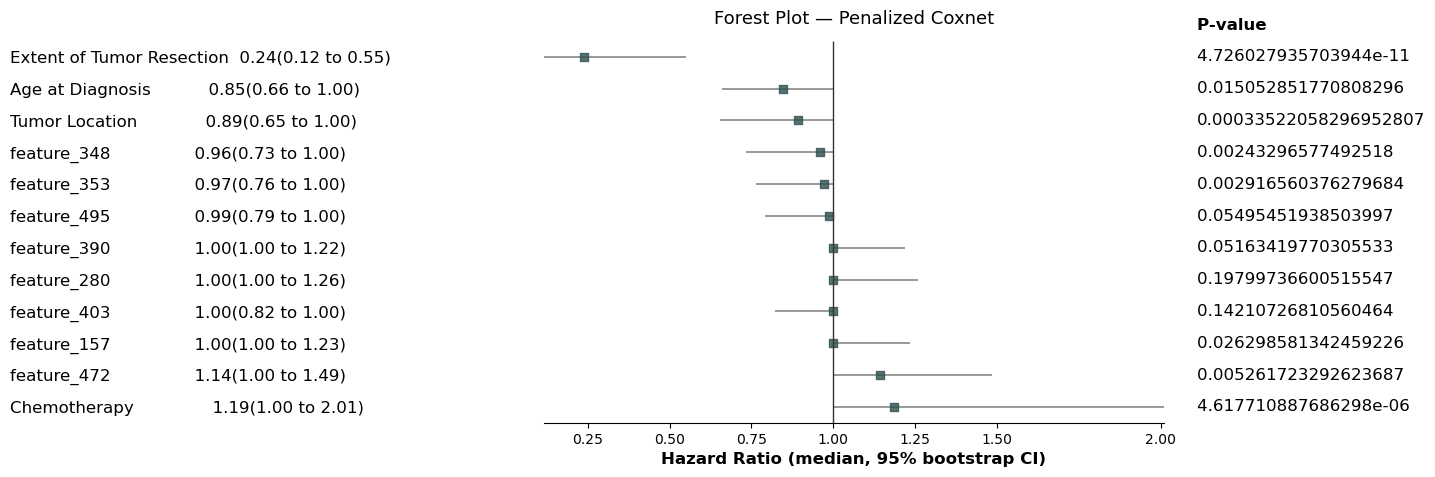

In [896]:
# ============================================================
# FOREST PLOT USING forestplot PACKAGE
# ============================================================
# Install if needed (run once)
# !pip install forestplot

import forestplot as fp

# -----------------------
# Prepare dataframe for forestplot
# -----------------------
fp_df = forest_filt.copy()

# forestplot needs: estimate, ll, hl, varlabel, pval
fp_df["estimate"] = fp_df["HR_Median"]
fp_df["ll"]       = fp_df["HR_2.5%"]
fp_df["hl"]       = fp_df["HR_97.5%"]
fp_df["varlabel"] = fp_df["Feature"]
fp_df["pval"]     = fp_df["p_uni"]

# Format HR + CI as a string annotation (shown on left)
fp_df["est_ci"] = (
    fp_df["HR_Median"].round(2).astype(str)
    + " ("
    + fp_df["HR_2.5%"].round(2).astype(str)
    + "–"
    + fp_df["HR_97.5%"].round(2).astype(str)
    + ")"
)

# Sort by HR for readability
fp_df = fp_df.sort_values("estimate")

# -----------------------
# Plot
# -----------------------
ax = fp.forestplot(
    fp_df,
    estimate="estimate",
    ll="ll",
    hl="hl",
    varlabel="varlabel",
    pval="pval",
    annote=["est_ci"],
    annoteheaders=["HR (95% CI)"],
    rightannote=["pval"],
    right_annoteheaders=["P-value"],
    xlabel="Hazard Ratio (median, 95% bootstrap CI)",
    xline=1.0,                        # reference line at HR=1
    figsize=(8, 5),
    **{
        "markersize" : 40,
        "fontfamily": "sans-serif",
        "linewidth"  : 2,
        "xticks"     : [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0],
    }
)

ax.set_title("Forest Plot — Penalized Coxnet", pad=10, fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "bootstrap_forest_plot.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

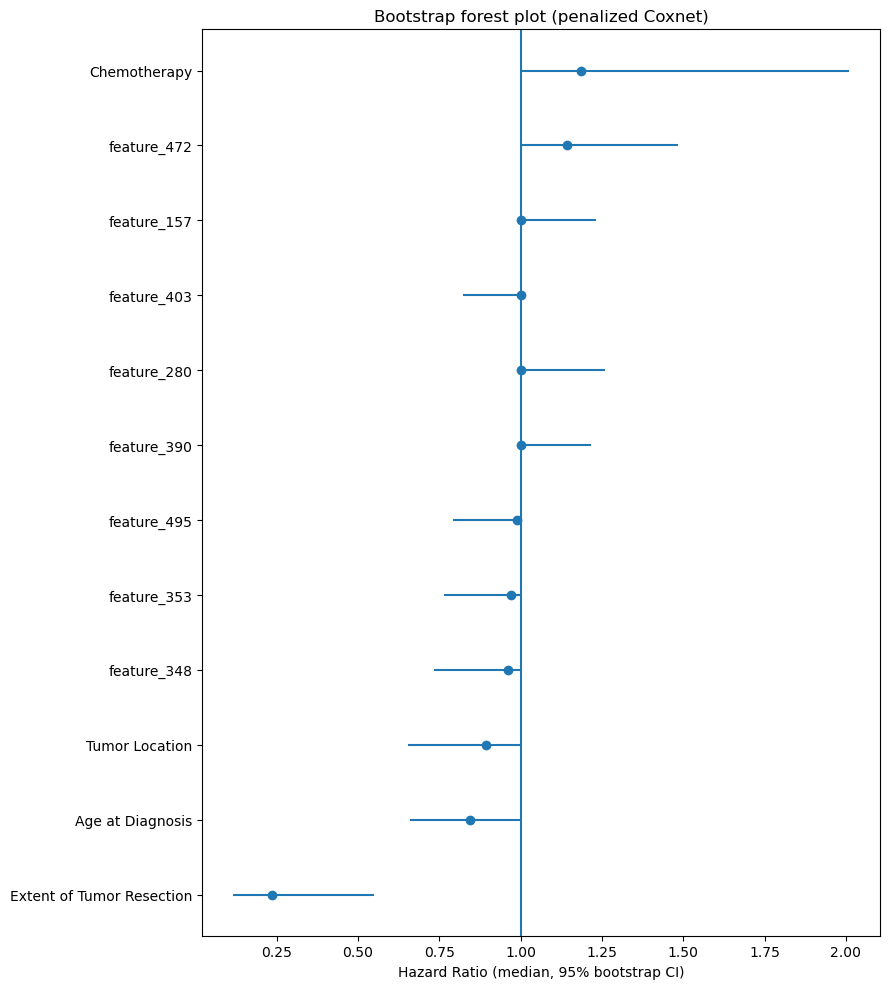

In [881]:
import matplotlib.pyplot as plt
import numpy as np

top = forest_filt.sort_values("Selection_Frequency", ascending=False).head(25).copy()
top = top.sort_values("HR_Median")  # nice ordering

ypos = np.arange(len(top))

plt.figure(figsize=(9, 10))
plt.errorbar(
    top["HR_Median"],
    ypos,
    xerr=[top["HR_Median"] - top["HR_2.5%"], top["HR_97.5%"] - top["HR_Median"]],
    fmt="o"
)
plt.axvline(1.0)
plt.yticks(ypos, top["Feature"])
plt.xlabel("Hazard Ratio (median, 95% bootstrap CI)")
plt.title("Bootstrap forest plot (penalized Coxnet)")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "bootstrap_forest_plot.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()


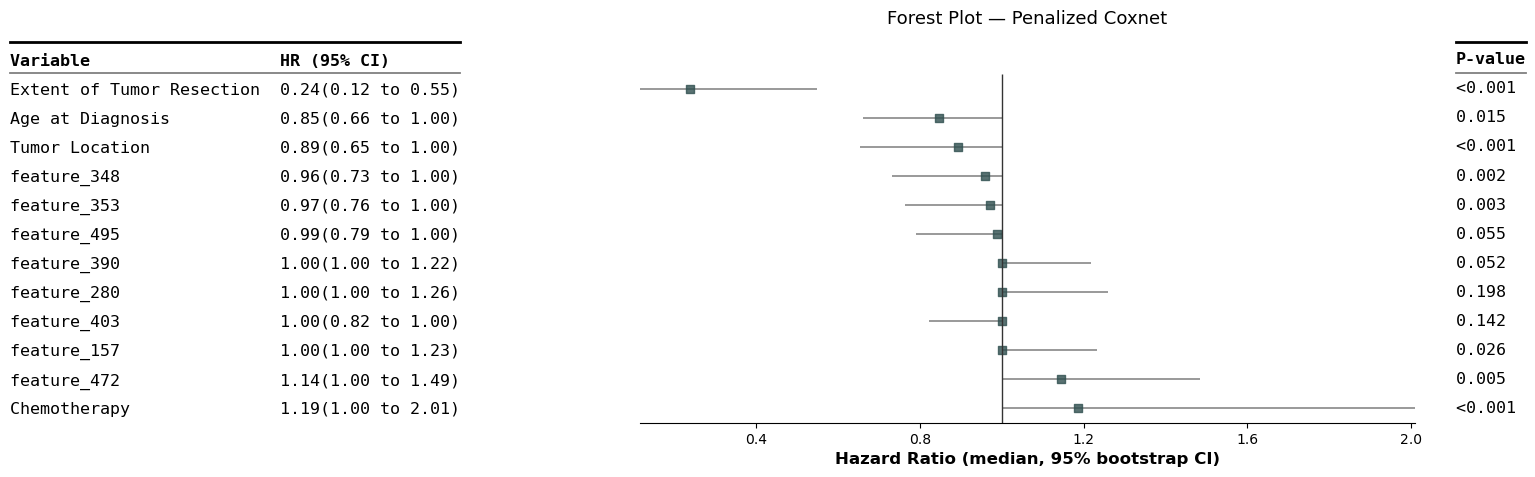

In [902]:
# ============================================================
# FOREST PLOT USING forestplot PACKAGE
# ============================================================
import forestplot as fp

# -----------------------
# Prepare dataframe
# -----------------------
fp_df = forest_filt.copy()

fp_df["estimate"] = fp_df["HR_Median"]
fp_df["ll"]       = fp_df["HR_2.5%"]
fp_df["hl"]       = fp_df["HR_97.5%"]
fp_df["varlabel"] = fp_df["Feature"]
fp_df["p_uni"]    = fp_df["p_uni"].astype(float)

# CI string: "0.91 (0.74 to 1.05)"
fp_df["est_ci"] = (
    fp_df["HR_Median"].round(2).astype(str)
    + " ("
    + fp_df["HR_2.5%"].round(2).astype(str)
    + " to "
    + fp_df["HR_97.5%"].round(2).astype(str)
    + ")"
)

# Pre-formatted p-value string
fp_df["pval_display"] = fp_df["p_uni"].apply(
    lambda p: "<0.001" if p < 0.001 else f"{p:.3f}"
)

# Sort by HR
fp_df = fp_df.sort_values("estimate")

# -----------------------
# Plot
# -----------------------
ax = fp.forestplot(
    fp_df,
    estimate="estimate",
    ll="ll",
    hl="hl",
    varlabel="varlabel",
    pval="p_uni",
    starpval=False,
    ci_report=False,                      # we supply our own CI string
    annote=["est_ci"],                    # left table: our CI string
    annoteheaders=["HR (95% CI)"],
    rightannote=["pval_display"],         # right table: p-value
    right_annoteheaders=["P-value"],
    xlabel="Hazard Ratio (median, 95% bootstrap CI)",
    xline=1.0,
    table=True,                           # <-- enables the clean table layout
    figsize=(10, 5),

)

ax.set_title("Forest Plot — Penalized Coxnet", pad=10, fontsize=13)
plt.savefig(os.path.join(plots_dir, "bootstrap_forest_plot.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [882]:
# Coefficient + Hazard Ratio table (robust to coef_ shape)
coef_vec = np.asarray(estimator.coef_).reshape(-1)   # or .ravel() / .squeeze()

coef = pd.DataFrame({"coef": coef_vec}, index=X_discovery.columns)

# keep non-zeros (tolerance helps with tiny numerical noise)
tol = 1e-12
coef = coef.loc[np.abs(coef["coef"]) > tol].copy()

coef["HR"] = np.exp(coef["coef"])
coef = coef.sort_values("HR", ascending=False)

coef.to_csv(os.path.join(data_dir, "coef_hr_table.csv"))
coef.head(20)


,coef,HR
Chemotherapy,0.198857,1.220008
feature_472,0.161282,1.175016
feature_157,0.008133,1.008166
feature_390,0.004000,1.004008
feature_280,0.002987,1.002991
feature_403,-0.000374,0.999627
feature_495,-0.019021,0.981159
feature_353,-0.053382,0.948018
feature_348,-0.080610,0.922554
Tumor Location,-0.132706,0.875722


# 3. Replicate

## 3.1 Predict

In [883]:
# Predict on replicate
pred_rep = estimator.predict(X_replicate)

# Harrell on replicate
har = concordance_index_censored(
    y_replicate["Event"], y_replicate["Progression Free Survival"], pred_rep
)[0]

# Uno on replicate (IPCW weights from DISCOVERY)
tau = float(np.percentile(
    y_discovery['Progression Free Survival'][y_discovery['Event']], 99
))
uno = concordance_index_ipcw(y_discovery, y_replicate, pred_rep, tau=tau)[0]

print("Replication Harrell:", har)
print("Replication Uno:", uno)

with open(os.path.join(metrics_dir, "replicate_metrics.txt"), "w") as f:
    f.write(f"Harrell's C-index: {har:.6f}\n")
    f.write(f"Uno's C-index (train=discovery): {uno:.6f}\n")


Replication Harrell: 0.7029177718832891
Replication Uno: 0.7352633966833578


## 3.2 Group Risk Scores

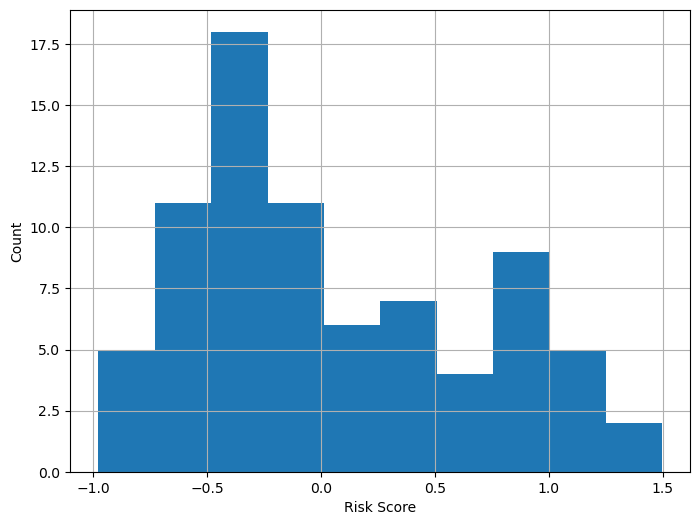

In [884]:
with open(os.path.join(data_dir, "risk_threshold.pkl"), "rb") as f:
    median_threshold = pickle.load(f)["median_threshold"]

risk_replicate = pd.DataFrame(
    {"Risk Score": estimator.predict(X_replicate)},
    index=X_replicate.index
)
risk_replicate["Event"] = y_replicate["Event"].astype(int)
risk_replicate["Progression Free Survival"] = y_replicate["Progression Free Survival"].astype(float)

risk_replicate["Risk Group"] = np.where(
    risk_replicate["Risk Score"] > median_threshold, "High", "Low"
)

with open(os.path.join(data_dir, "replicate_results.pkl"), "wb") as f:
    pickle.dump(risk_replicate, f)

# ✅ Also save as CSV
risk_replicate.to_csv(os.path.join(data_dir, "replicate_results.csv"), index=True)

plt.figure(figsize=(8, 6))
risk_replicate["Risk Score"].hist(bins=bins(risk_replicate.shape[0]))
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.savefig(os.path.join(plots_dir, "replicate_risk_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [885]:
with open(os.path.join(data_dir, "risk_threshold.pkl"), "rb") as f:
    median_threshold = pickle.load(f)["median_threshold"]
print("Median threshold (from discovery):", median_threshold)


Median threshold (from discovery): -0.1256426243281814


In [886]:
# combine replicate results with discovery in csv and save
with open(os.path.join(data_dir, "replicate_results.pkl"), "rb") as file:
    risk_replicate = pickle.load(file)
with open(os.path.join(data_dir, "discovery_results.pkl"), "rb") as file:
    risk_discovery = pickle.load(file)

# merge and make sure to label the cohorts
risk = pd.concat([risk_discovery, risk_replicate], axis=0)
risk["Cohort"] = ["Discovery"] * risk_discovery.shape[0] + ["Replicate"] * risk_replicate.shape[0]
risk.to_csv(os.path.join(data_dir, "risk_scores.csv"), index=True)
